In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
# HR Analytics - Data Preparation & EDA
# Author: Mohd Badruzama Ansari
# Dataset: IBM HR Analytics Employee Attrition

# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [11]:
# Load the dataset

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Shape of dataset
print("Dataset Shape:", df.shape)
print("\n")


df.head()

Dataset Shape: (1470, 35)




,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [6]:
# Checking dataset structure, missing values and duplicates
# IBM HR dataset is clean but verifying before any transformation

df.info()
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel  

In [12]:
# Summary statistics for numerical columns
print("Summary Statistics")
print(df.describe())

print()

# Total employees
total_employees = len(df)

# Count attrition values
attrition_count = df["Attrition"].value_counts()

# Employees who left
employees_left = attrition_count["Yes"]

# Calculate attrition rate
attrition_rate = (employees_left / total_employees) * 100

print("Total Employees:", total_employees)
print("Employees Left:", employees_left)
print("Attrition Rate:", round(attrition_rate, 2), "%")

Summary Statistics
               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602

In [13]:
print(df[["EmployeeCount", "Over18", "StandardHours"]].nunique())

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64


In [14]:
# Converting Attrition column from Yes/No to 1/0 for numeric analysis
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Dropping columns that have no analytical value
# EmployeeCount, Over18 and StandardHours have same value for all rows
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], inplace=True)

# Verifying the changes
print("Columns after cleaning:", df.shape[1])
print("Attrition_Flag sample:\n", df['Attrition_Flag'].value_counts())

Columns after cleaning: 33
Attrition_Flag sample:
 Attrition_Flag
0    1233
1     237
Name: count, dtype: int64


In [15]:
# Calculate attrition rate department-wise

dept_attrition = df.groupby("Department")["Attrition_Flag"].mean()

# Convert to percentage
dept_attrition = dept_attrition * 100

# Round values
dept_attrition = dept_attrition.round(2)

# Sort from highest to lowest
dept_attrition = dept_attrition.sort_values(ascending=False)

# Display result
print("Department Wise Attrition Rate")
print(dept_attrition)

Department Wise Attrition Rate
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition_Flag, dtype: float64


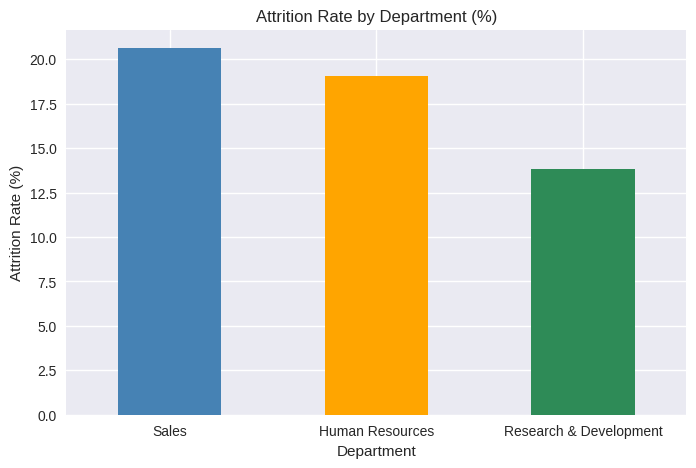

In [19]:
dept_attrition.plot(kind="bar",color=['steelblue', 'orange', 'seagreen'], figsize=(8,5))

plt.title("Attrition Rate by Department (%)")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.show()

In [22]:
# Create Age Groups

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 60],
    labels=["18-25", "26-35", "36-45", "46-60"])

# Calculate attrition rate for each age group

age_attrition = df.groupby("Age_Group", observed=True)["Attrition_Flag"].mean()

# Convert to percentage

age_attrition = age_attrition * 100
age_attrition = age_attrition.round(2)

print("Attrition Rate by Age Group (%)")
print(age_attrition)


Attrition Rate by Age Group (%)
Age_Group
18-25    34.78
26-35    19.14
36-45     9.19
46-60    12.45
Name: Attrition_Flag, dtype: float64


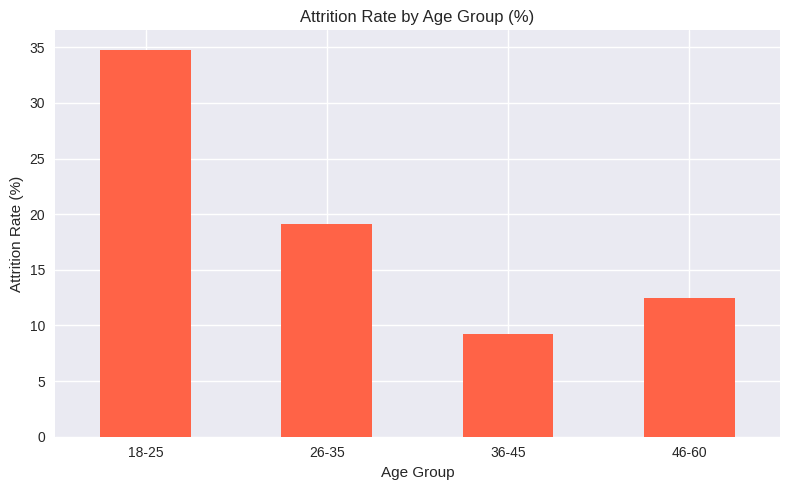

In [23]:
#  bar chart

age_attrition.plot(
    kind="bar",
    color="tomato",
    figsize=(8,5)
)

plt.title("Attrition Rate by Age Group (%)")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [26]:
# Calculate attrition rate by job role
role_attrition = df.groupby("JobRole")["Attrition_Flag"].mean()

# Convert to percentage
role_attrition = role_attrition * 100
role_attrition = role_attrition.round(2).sort_values(ascending=True)

print("Attrition Rate by Job Role (%)")
print(role_attrition)

Attrition Rate by Job Role (%)
JobRole
Research Director             2.50
Manager                       4.90
Healthcare Representative     6.87
Manufacturing Director        6.90
Research Scientist           16.10
Sales Executive              17.48
Human Resources              23.08
Laboratory Technician        23.94
Sales Representative         39.76
Name: Attrition_Flag, dtype: float64


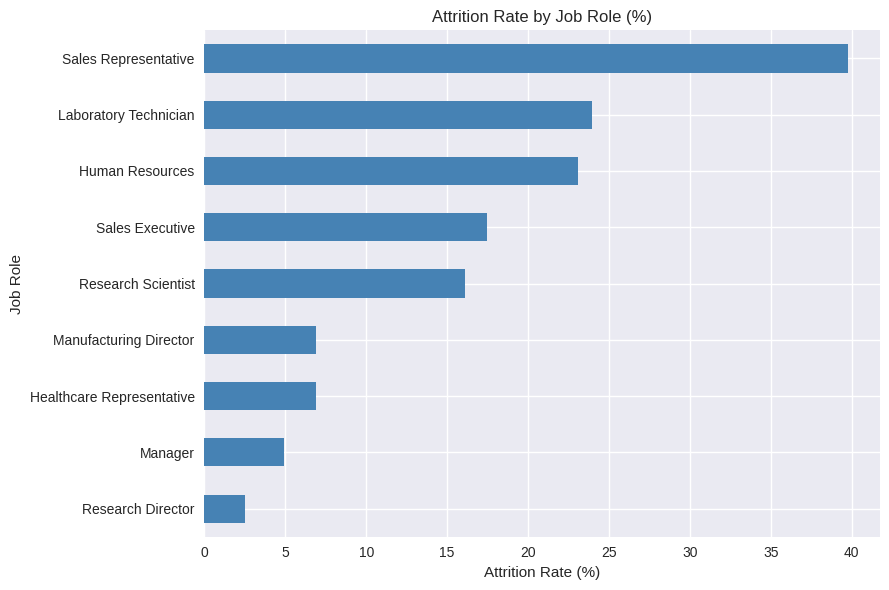

In [27]:
# chart

role_attrition.plot(
    kind="barh",
    color="steelblue",
    figsize=(9,6))

plt.title("Attrition Rate by Job Role (%)")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.tight_layout()

plt.show()

In [29]:
# Calculate average monthly income

salary_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(2)


print("Average Monthly Income by Attrition")
print(salary_attrition)



Average Monthly Income by Attrition:
 Attrition
No     6832.74
Yes    4787.09
Name: MonthlyIncome, dtype: float64


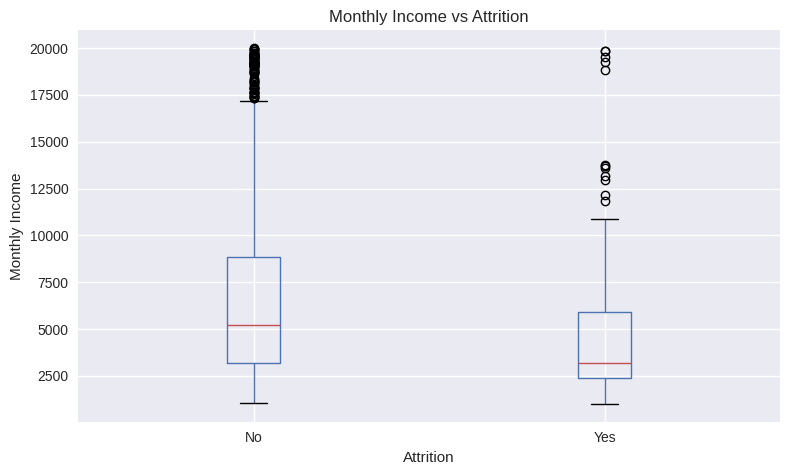

In [30]:
#boxplot

df.boxplot(
    column="MonthlyIncome",
    by="Attrition",
    figsize=(8,5)
)

plt.title("Monthly Income vs Attrition")

plt.suptitle("")

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.show()

In [37]:
# Work Life Balance

wlb = df.groupby("WorkLifeBalance")["Attrition_Flag"].mean().round(2)

wlb = wlb * 100

print("Attrition Rate by Work Life Balance")
print(wlb)

# Job Satisfaction

js = df.groupby("JobSatisfaction")["Attrition_Flag"].mean().round(2)

js = js * 100

print("\nAttrition Rate by Job Satisfaction")
print(js)

Attrition Rate by Work Life Balance
WorkLifeBalance
1    31.0
2    17.0
3    14.0
4    18.0
Name: Attrition_Flag, dtype: float64

Attrition Rate by Job Satisfaction
JobSatisfaction
1    23.0
2    16.0
3    17.0
4    11.0
Name: Attrition_Flag, dtype: float64


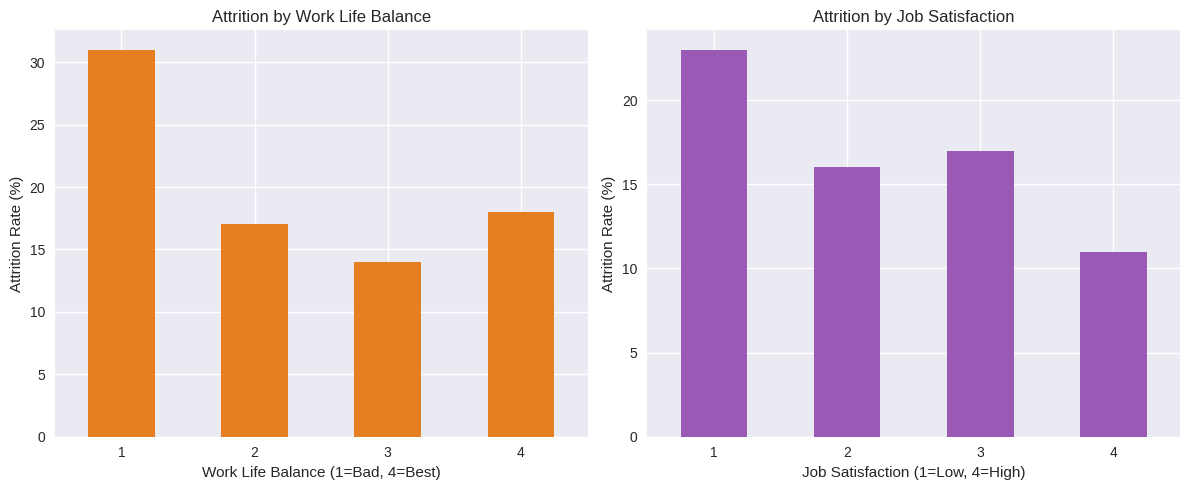

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Work Life Balance Chart
wlb.plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('Attrition by Work Life Balance')
axes[0].set_xlabel('Work Life Balance (1=Bad, 4=Best)')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(rotation=0)

# Job Satisfaction Chart
js.plot(kind='bar', ax=axes[1], color='purple')
axes[1].set_title('Attrition by Job Satisfaction')
axes[1].set_xlabel('Job Satisfaction (1=Low, 4=High)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

In [39]:
# Exporting cleaned dataset to use in SQL analysis
# file will be imported into MySQL Workbench

df.to_csv('hr_analytics_cleaned.csv', index=False)

print("Cleaned dataset exported successfully!")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Cleaned dataset exported successfully!
Total Rows: 1470
Total Columns: 34
